# 07 — การกระจายวงเงินสัญญาก่อสร้างของ 8 หน่วยงานที่มีสัญญามากที่สุด

Notebook นี้ใช้ข้อมูล **ปีงบประมาณ 2569 (ข้อมูล ณ 30 กรกฎาคม 2569)** จากไฟล์สัญญาก่อสร้าง ในหัวข้อ 2 ของ README โดยนับ **1 แถว = 1 รายการสัญญา** ไม่ใช่ 1 โครงการ

เลือก 8 หน่วยงานจาก **จำนวนรายการสัญญาก่อสร้าง** มากที่สุดเท่านั้น ไม่ใช้จำนวนโครงการประเภทอื่นหรือวงเงินรวมจัดอันดับ หากไฟล์มีคอลัมน์ประเภทโครงการ จะคัดเฉพาะ `จ้างก่อสร้าง` อีกครั้ง แล้วเปรียบเทียบวงเงินงบประมาณในสัญญา 2 มุมมอง: ช่วงราคาไม่เกิน 1 ล้านบาท และช่วง 300,000–600,000 บาท แกนราคาทั้งสองด้านใช้ตัวเลขปกติที่เพิ่มขึ้นเท่า ๆ กัน ตัวเลขข้างกราฟระบุจำนวนสัญญาที่อยู่ในช่วง **490,000–500,000 บาท** เทียบกับสัญญาก่อสร้างทั้งหมดของหน่วยงานนั้น

กราฟเน้นช่วงราคาไม่เกิน 1 ล้านบาทเพื่อให้เห็นตำแหน่งของ 500,000 บาทได้ชัดเจน สัญญาที่ราคาเกิน 1 ล้านบาทไม่ได้ถูกวาด แต่ยังนับในจำนวนสัญญาทั้งหมดและแสดงในตารางสรุป Violin plot แสดงว่าช่วงราคาใดพบบ่อย จึง **ไม่ใช้ความกว้างของรูปทรงเปรียบเทียบจำนวนสัญญาระหว่างหน่วยงาน** การพบสัญญาใกล้ 500,000 บาทมากไม่ได้เป็นข้อพิสูจน์ความผิดปกติด้วยตัวเอง


## 1. ตั้งค่าและอ่านข้อมูลจาก Google Drive
Run all ได้โดยไม่ต้อง Mount Drive: Notebook จะดาวน์โหลดไฟล์ที่แชร์ลงพื้นที่ชั่วคราวของ Colab หากมีไฟล์ใน Drive ของตนเองอยู่แล้ว ให้ตั้ง `LOCAL_DATA_DIR` เพื่อลดเวลารอ เปิด `SAVE_FIGURE` เฉพาะเมื่อต้องการบันทึก PNG และ SVG ลง Drive

In [1]:
# ============================================================
# 1) PARAMETERS : ตำแหน่งข้อมูลและรูปผลลัพธ์
# ============================================================
from pathlib import Path
import atexit
import gc
import importlib.util
import shutil
import subprocess
import sys
import tempfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from google.colab import drive
from IPython.display import display

YEAR = 2569
SAVE_FIGURE = False  # เปลี่ยนเป็น True เมื่อต้องการบันทึกรูปลง Drive
LOCAL_DATA_DIR = None  # ถ้ามีไฟล์อยู่แล้ว ใช้ '/content/drive/MyDrive/DADS5001/project_1_dads5001/data_for_github'
FIGURE_DIR = Path(f'/content/drive/MyDrive/DADS5001/project_1_dads5001/notebook/overview_output/{YEAR}/analysis_output/figures')
INPUT_NAME = f'construction_contract_supplier_study_scope_{YEAR}.csv'
FIGURE_NAME = f'07_top8_construction_contract_value_violin_{YEAR}'

# ใช้ไฟล์ที่ผู้รันระบุ หรือดาวน์โหลดไฟล์ snapshot รุ่นเดียวกับ Notebook 05
if globals().get('_download_runtime') is not None:
    _download_runtime.cleanup()
_download_runtime = None
if LOCAL_DATA_DIR is not None:
    if str(LOCAL_DATA_DIR).startswith('/content/drive/') and not Path('/content/drive/MyDrive').is_dir():
        drive.mount('/content/drive')
    INPUT_FILE = Path(LOCAL_DATA_DIR) / INPUT_NAME
    if not INPUT_FILE.is_file():
        raise FileNotFoundError(f'ไม่พบไฟล์ {INPUT_FILE}; กรุณาตรวจ LOCAL_DATA_DIR')
else:
    if importlib.util.find_spec('gdown') is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'], check=True)  # รอจนติดตั้งเสร็จ ไม่มี worker ค้าง
    import gdown
    _download_runtime = tempfile.TemporaryDirectory(prefix='construction_violin_')
    atexit.register(_download_runtime.cleanup)
    INPUT_FILE = Path(_download_runtime.name) / INPUT_NAME
    expected_bytes = 243_311_179  # ขนาดไฟล์ใน data_manifest.json รุ่นที่ใช้กับ Pae
    if shutil.disk_usage(INPUT_FILE.parent).free < expected_bytes + 512 * 1024**2:
        raise OSError('พื้นที่ชั่วคราวของ Colab ไม่พอสำหรับไฟล์ข้อมูล')
    try:
        downloaded = gdown.download(id='1dXH9N4ukZAabRQwl9nkQ-KidB1e80ZAh', output=str(INPUT_FILE), quiet=False)
        if downloaded is None or not INPUT_FILE.is_file() or INPUT_FILE.stat().st_size != expected_bytes:
            raise IOError('ดาวน์โหลดไฟล์ไม่ครบหรือรุ่นข้อมูลเปลี่ยน กรุณาตรวจสิทธิ์ไฟล์ใน data_for_github')
    except Exception:
        _download_runtime.cleanup()  # ลบไฟล์ดาวน์โหลดที่ไม่สมบูรณ์ทันที
        raise

# ตรวจ RAM ก่อนอ่านไฟล์ใหญ่; ไม่ฝืนทำงานเมื่อ RAM ใช้สูง
try:
    import psutil
    ram_percent = psutil.virtual_memory().percent
    print(f'RAM ก่อนอ่านข้อมูล: {ram_percent:.1f}%')
    if ram_percent >= 80:
        gc.collect()
        if psutil.virtual_memory().percent >= 80:
            raise MemoryError('RAM ใช้ตั้งแต่ 80% ขึ้นไป กรุณา Restart runtime ก่อน Run all ใหม่')
except ImportError:
    print('ไม่พบ psutil; อ่านข้อมูลเฉพาะสองคอลัมน์แบบแบ่งส่วนเพื่อประหยัด RAM')

# ติดตั้งฟอนต์ไทยสำหรับ Matplotlib โดยเก็บเฉพาะในพื้นที่ชั่วคราวของ Colab
font_path = Path('/content/NotoSansThai.ttf')
font_url = 'https://raw.githubusercontent.com/google/fonts/main/ofl/notosansthai/NotoSansThai%5Bwdth%2Cwght%5D.ttf'
if not font_path.is_file():
    urllib.request.urlretrieve(font_url, font_path)
font_manager.fontManager.addfont(str(font_path))
plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(font_path)).get_name()
plt.rcParams['axes.unicode_minus'] = False
print('ไฟล์ข้อมูล:', INPUT_FILE)


Downloading...
From (original): https://drive.google.com/uc?id=1dXH9N4ukZAabRQwl9nkQ-KidB1e80ZAh
From (redirected): https://drive.google.com/uc?id=1dXH9N4ukZAabRQwl9nkQ-KidB1e80ZAh&confirm=t&uuid=60c214e3-854c-47ec-afa3-947c561dec40
To: /tmp/construction_violin_y590vcgh/construction_contract_supplier_study_scope_2569.csv
100%|██████████| 243M/243M [00:02<00:00, 97.8MB/s]


RAM ก่อนอ่านข้อมูล: 8.7%
ไฟล์ข้อมูล: /tmp/construction_violin_y590vcgh/construction_contract_supplier_study_scope_2569.csv


## 2. ตรวจข้อมูลและจัดอันดับหน่วยงาน
อ่านเฉพาะคอลัมน์ที่จำเป็นแบบแบ่งส่วนและคัดเฉพาะสัญญาประเภทจ้างก่อสร้างก่อนจัดอันดับ สัญญาที่มีชื่อหน่วยงานแต่ไม่มีวงเงินบวกยังนับในอันดับตามจำนวนสัญญา เพียงแต่ไม่วาดในกราฟ

In [2]:
# ============================================================
# 2) DATA : อ่านเฉพาะคอลัมน์จำเป็นและตรวจความครบถ้วน
# ============================================================
agency_col = 'ชื่อหน่วยงาน'
value_col = 'วงเงินงบประมาณในสัญญา (บาท)'
project_type_col = 'ชื่อประเภทโครงการ'
header_cols = pd.read_csv(INPUT_FILE, nrows=0).columns
missing_cols = [col for col in (agency_col, value_col) if col not in header_cols]
if missing_cols:
    raise KeyError(f'ไฟล์ข้อมูลขาดคอลัมน์: {missing_cols}')
has_project_type = project_type_col in header_cols
read_cols = [agency_col, value_col] + ([project_type_col] if has_project_type else [])
read_dtypes = {agency_col: 'string'}
if has_project_type:
    read_dtypes[project_type_col] = 'string'
else:
    print('หมายเหตุ: ไฟล์ไม่มีคอลัมน์ประเภทโครงการ จึงใช้ขอบเขตสัญญาก่อสร้างของไฟล์ต้นทางโดยตรง')

chunks = []
source_rows = 0
construction_rows = 0
# ตัวอ่านแบบ with ปิด file handle ให้ทันทีเมื่ออ่านเสร็จ
with pd.read_csv(INPUT_FILE, usecols=read_cols, dtype=read_dtypes, chunksize=100_000, low_memory=False) as reader:
    for chunk in reader:
        source_rows += len(chunk)
        # ไฟล์จาก Pae เป็นข้อมูลสัญญาก่อสร้างอยู่แล้ว; ถ้ามีประเภทโครงการให้ตรวจซ้ำทีละแถว
        if has_project_type:
            chunk = chunk.loc[chunk[project_type_col].str.strip().eq('จ้างก่อสร้าง').fillna(False)]
        construction_rows += len(chunk)
        if chunk.empty:
            continue
        chunk[value_col] = pd.to_numeric(chunk[value_col], errors='coerce')
        valid_name = chunk[agency_col].notna() & chunk[agency_col].str.strip().ne('')
        chunks.append(chunk.loc[valid_name, [agency_col, value_col]])
        del chunk
if construction_rows == 0 or not chunks:
    raise ValueError('ไม่พบสัญญาประเภทจ้างก่อสร้างที่มีชื่อหน่วยงานในไฟล์')
contract_value_df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()
print(f'รายการทั้งหมดในไฟล์: {source_rows:,}')
print(f'สัญญาก่อสร้างที่ใช้จัดอันดับ: {construction_rows:,}')
valid_price_count = int(contract_value_df[value_col].gt(0).sum())
print(f'สัญญาก่อสร้างที่มีชื่อหน่วยงานและวงเงินบวก: {valid_price_count:,}')
print(f'สัญญาก่อสร้างที่ไม่วาดเพราะชื่อหน่วยงาน/วงเงินไม่ครบหรือวงเงินไม่เป็นบวก: {construction_rows - valid_price_count:,}')
if construction_rows != 179_716:
    print('หมายเหตุ: จำนวนสัญญาก่อสร้างต่างจากตัวเลข 179,716 ใน README; โปรดตรวจรุ่นไฟล์ก่อนนำกราฟไปเผยแพร่')

# จัดอันดับจากจำนวนรายการสัญญาก่อสร้างทั้งหมด ไม่ใช่วงเงินรวม
agency_counts = contract_value_df[agency_col].value_counts().head(8)
if len(agency_counts) < 8:
    raise ValueError('พบหน่วยงานที่มีข้อมูลไม่ถึง 8 หน่วยงาน')
top_agencies = agency_counts.index.tolist()
top_value_df = contract_value_df.loc[contract_value_df[agency_col].isin(top_agencies) & contract_value_df[value_col].gt(0)]
if top_value_df[agency_col].nunique() < 8:
    raise ValueError('หน่วยงาน 8 อันดับแรกบางแห่งไม่มีวงเงินบวก จึงยังวาดกราฟเทียบกันไม่ได้')
within_1m_counts = top_value_df.loc[top_value_df[value_col].le(1_000_000), agency_col].value_counts()
near_mask = top_value_df[value_col].between(490_000, 500_000, inclusive='both')
near_counts = top_value_df.loc[near_mask, agency_col].value_counts()
top8_summary_df = pd.DataFrame({
    'ชื่อหน่วยงาน': top_agencies,
    'จำนวนสัญญาก่อสร้าง': agency_counts.to_numpy(dtype=int),
    'จำนวนสัญญาไม่เกิน 1 ล้านบาท': [int(within_1m_counts.get(name, 0)) for name in top_agencies],
    'จำนวนสัญญา 490,000–500,000 บาท': [int(near_counts.get(name, 0)) for name in top_agencies]
})
top8_summary_df['สัดส่วนใกล้ 500,000 บาท (%)'] = 100 * top8_summary_df['จำนวนสัญญา 490,000–500,000 บาท'] / top8_summary_df['จำนวนสัญญาก่อสร้าง']
display(top8_summary_df.style.format({'จำนวนสัญญาก่อสร้าง': '{:,.0f}', 'จำนวนสัญญาไม่เกิน 1 ล้านบาท': '{:,.0f}', 'จำนวนสัญญา 490,000–500,000 บาท': '{:,.0f}', 'สัดส่วนใกล้ 500,000 บาท (%)': '{:,.1f}%'}))


รายการทั้งหมดในไฟล์: 179,716
สัญญาก่อสร้างที่ใช้จัดอันดับ: 179,716
สัญญาก่อสร้างที่มีชื่อหน่วยงานและวงเงินบวก: 179,626
สัญญาก่อสร้างที่ไม่วาดเพราะชื่อหน่วยงาน/วงเงินไม่ครบหรือวงเงินไม่เป็นบวก: 90


,ชื่อหน่วยงาน,จำนวนสัญญาก่อสร้าง,จำนวนสัญญาไม่เกิน 1 ล้านบาท,"จำนวนสัญญา 490,000–500,000 บาท","สัดส่วนใกล้ 500,000 บาท (%)"
0,กรมทางหลวง,"5,849",710,199,3.4%
1,กรมทางหลวงชนบท,"5,547","2,291","1,860",33.5%
2,กรมการปกครอง,"4,463","3,983",638,14.3%
3,กรมพัฒนาที่ดิน,"3,737","3,536",45,1.2%
4,การไฟฟ้าส่วนภูมิภาค,"3,198","3,088",67,2.1%
5,กรมชลประทาน,"2,422","1,305",203,8.4%
6,การประปาส่วนภูมิภาค,"2,027","1,488",28,1.4%
7,กรุงเทพมหานคร,"1,001",427,93,9.3%


## 3. Violin plot — วงเงินไม่เกิน 1 ล้านบาท และช่วงใกล้ 500,000 บาท
ทั้งสองแผงใช้แกนราคาแบบปกติ ไม่ใช่ลอการิทึม แผงซ้ายแสดงเฉพาะสัญญาราคาไม่เกิน 1 ล้านบาท แผงขวาดูใกล้ขึ้นในช่วง 300,000–600,000 บาท และระบายแถบ 490,000–500,000 บาท สัญญาที่ราคาเกิน 1 ล้านบาทยังรวมอยู่ในจำนวนสัญญาทั้งหมดที่ใช้จัดอันดับ แต่ไม่ได้วาดในกราฟนี้

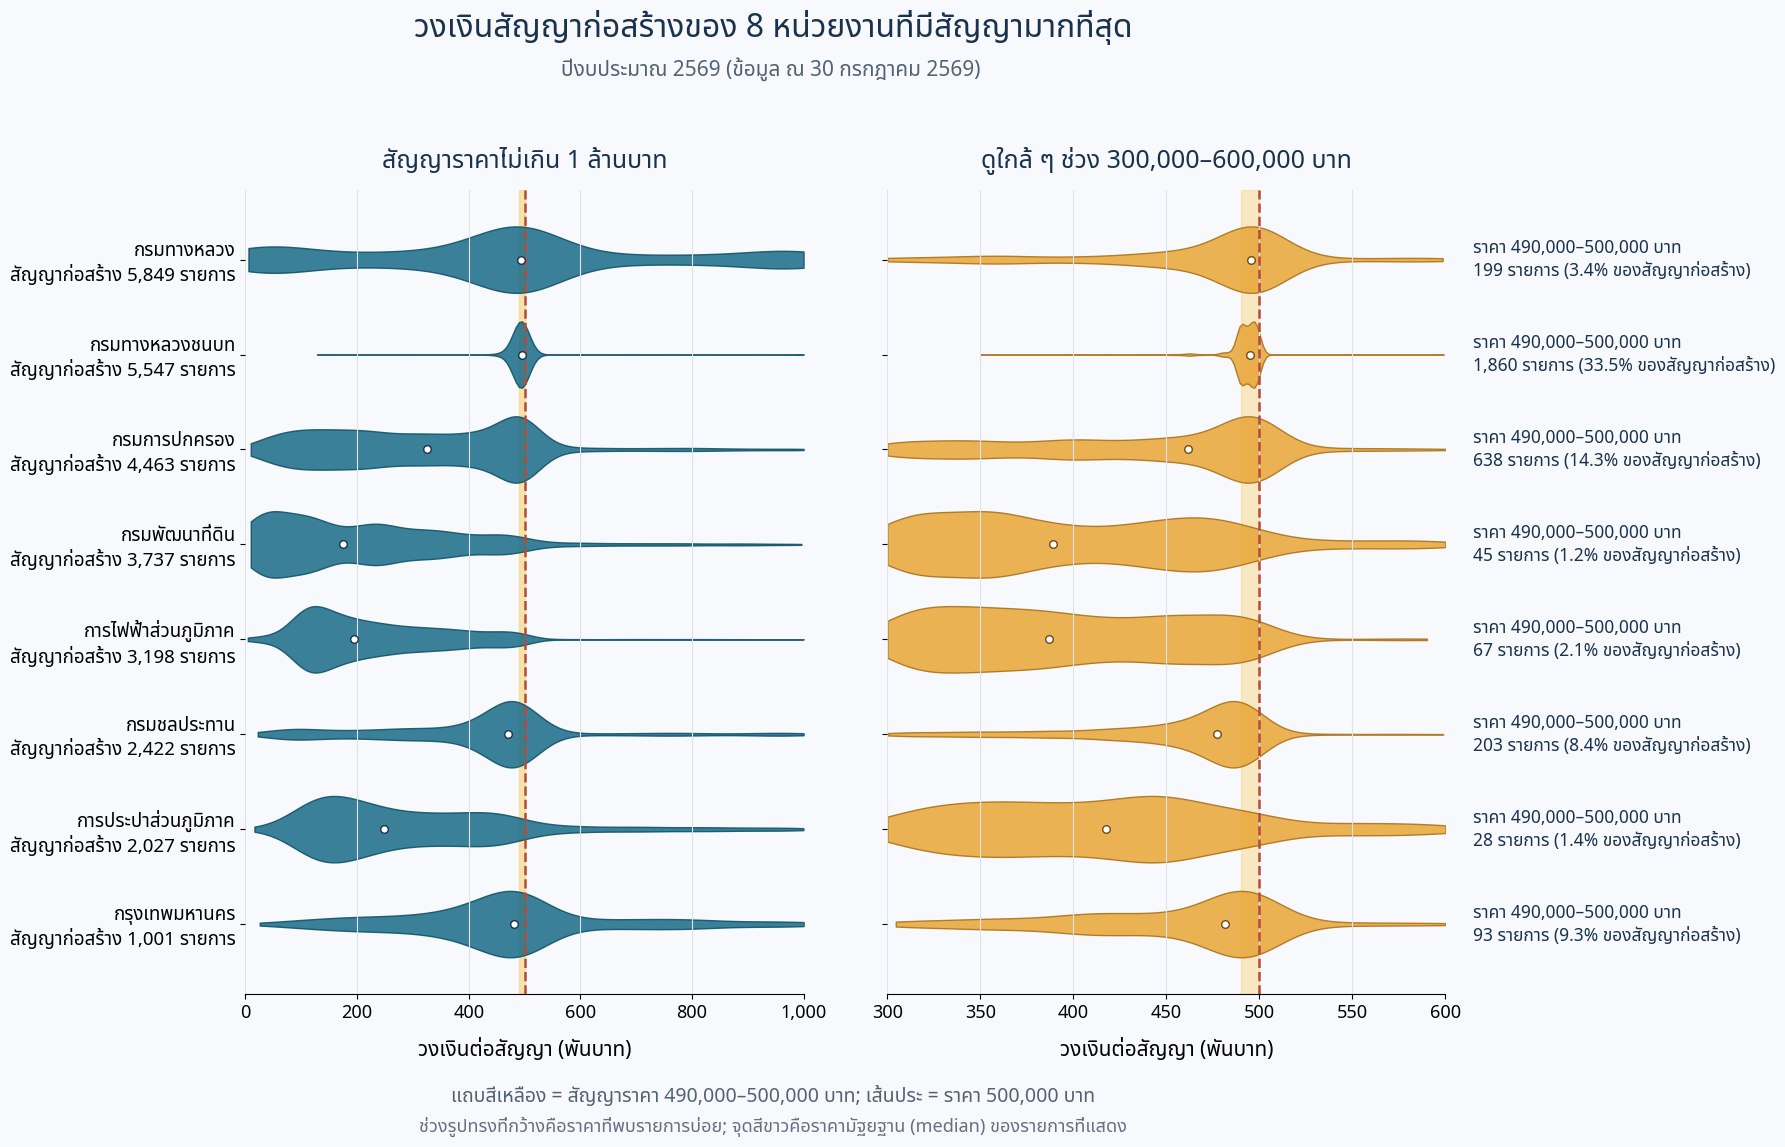

ปิด Figure และ file handle แล้ว; ลบไฟล์พักที่ดาวน์โหลด และเก็บ DataFrame สรุปไว้ตรวจสอบต่อ


In [3]:
# ============================================================
# 3) PLOT : เทียบการกระจายวงเงินของ 8 หน่วยงานในสองช่วงราคา
# ============================================================
if 'psutil' in globals() and psutil.virtual_memory().percent >= 80:
    gc.collect()
    if psutil.virtual_memory().percent >= 80:
        raise MemoryError('RAM ใช้ตั้งแต่ 80% ขึ้นไปก่อนวาดกราฟ กรุณา Restart runtime')

fig, (ax_overview, ax_zoom) = plt.subplots(1, 2, figsize=(24, 12), sharey=True, facecolor='#F7F9FC')
positions = np.arange(len(top_agencies))[::-1]
for ax in (ax_overview, ax_zoom):
    ax.set_facecolor('#F7F9FC')
    ax.grid(axis='x', color='#DDE4EC', linewidth=0.8, zorder=0)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis='both', labelsize=13)

# วาดรูปทรงราคาแยกแต่ละหน่วยงาน โดยไม่เปลี่ยนราคาเป็น log
for pos, agency in zip(positions, top_agencies):
    all_values = top_value_df.loc[top_value_df[agency_col].eq(agency), value_col].to_numpy(dtype=float)
    overview_values = all_values[all_values <= 1_000_000]
    if len(overview_values) >= 2 and np.unique(overview_values).size > 1:
        violin = ax_overview.violinplot(overview_values, positions=[pos], vert=False, widths=0.70, showextrema=False, points=160)
        for body in violin['bodies']:
            body.set_facecolor('#176B87'); body.set_edgecolor('#0B4D64'); body.set_alpha(0.85)
        ax_overview.scatter(np.median(overview_values), pos, s=30, color='white', edgecolor='#19324D', zorder=4)
    elif len(overview_values):
        ax_overview.scatter(overview_values[0], pos, s=70, color='#176B87', zorder=3)
    else:
        ax_overview.text(500_000, pos, 'ไม่มีสัญญาในช่วงนี้', ha='center', va='center', fontsize=13, color='#667085')

    zoom_values = all_values[(all_values >= 300_000) & (all_values <= 600_000)]
    if len(zoom_values) >= 2 and np.unique(zoom_values).size > 1:
        violin = ax_zoom.violinplot(zoom_values, positions=[pos], vert=False, widths=0.70, showextrema=False, points=160)
        for body in violin['bodies']:
            body.set_facecolor('#E9A83B'); body.set_edgecolor('#A97018'); body.set_alpha(0.88)
        ax_zoom.scatter(np.median(zoom_values), pos, s=30, color='white', edgecolor='#6E4B16', zorder=4)
    elif len(zoom_values):
        ax_zoom.scatter(zoom_values[0], pos, s=70, color='#E9A83B', zorder=3)
    else:
        ax_zoom.text(450_000, pos, 'ไม่มีสัญญาในช่วงนี้', ha='center', va='center', fontsize=13, color='#667085')

# เขียนจำนวนสัญญาเป็นคำเต็ม แทนตัวอักษรย่อที่คนอ่านอาจไม่คุ้น
agency_labels = [f'{name}\nสัญญาก่อสร้าง {count:,} รายการ' for name, count in zip(top_agencies, agency_counts)]
ax_overview.set_yticks(positions, agency_labels, fontsize=13.5)
ax_zoom.tick_params(axis='y', labelleft=False)
ax_overview.axvspan(490_000, 500_000, color='#F7D67D', alpha=0.65, zorder=0)
ax_overview.axvline(500_000, color='#B54B3B', linestyle='--', linewidth=1.8)
ax_zoom.axvspan(490_000, 500_000, color='#F7D67D', alpha=0.46, zorder=0)
ax_zoom.axvline(500_000, color='#B54B3B', linestyle='--', linewidth=1.8)

ax_overview.set_xlim(0, 1_000_000)
ax_overview.set_xticks([0, 200_000, 400_000, 600_000, 800_000, 1_000_000], ['0', '200', '400', '600', '800', '1,000'])
ax_overview.set_xlabel('วงเงินต่อสัญญา (พันบาท)', fontsize=15, labelpad=12)
ax_overview.set_title('สัญญาราคาไม่เกิน 1 ล้านบาท', fontsize=18, color='#19324D', pad=16)
ax_zoom.set_xlim(300_000, 600_000)
ax_zoom.set_xticks([300_000, 350_000, 400_000, 450_000, 500_000, 550_000, 600_000], ['300', '350', '400', '450', '500', '550', '600'])
ax_zoom.set_xlabel('วงเงินต่อสัญญา (พันบาท)', fontsize=15, labelpad=12)
ax_zoom.set_title('ดูใกล้ ๆ ช่วง 300,000–600,000 บาท', fontsize=18, color='#19324D', pad=16)
for pos, row in zip(positions, top8_summary_df.itertuples(index=False, name=None)):
    _, total_count, within_1m_count, near_count, near_pct = row
    ax_zoom.text(1.05, pos, f'ราคา 490,000–500,000 บาท\n{near_count:,} รายการ ({near_pct:.1f}% ของสัญญาก่อสร้าง)', transform=ax_zoom.get_yaxis_transform(), clip_on=False, va='center', fontsize=12.5, color='#19324D', linespacing=1.35)

fig.suptitle('วงเงินสัญญาก่อสร้างของ 8 หน่วยงานที่มีสัญญามากที่สุด', fontsize=23, fontweight='bold', color='#19324D', y=0.98)
fig.text(0.5, 0.925, f'ปีงบประมาณ {YEAR} (ข้อมูล ณ 30 กรกฎาคม 2569) ', ha='center', fontsize=15, color='#526276')
fig.text(0.5, 0.070, 'แถบสีเหลือง = สัญญาราคา 490,000–500,000 บาท; เส้นประ = ราคา 500,000 บาท', ha='center', fontsize=14, color='#526276')

fig.text(0.5, 0.045, 'ช่วงรูปทรงที่กว้างคือราคาที่พบรายการบ่อย; จุดสีขาวคือราคามัฐยฐาน (median) ของรายการที่แสดง', ha='center', fontsize=13, color='#667085')
fig.subplots_adjust(left=0.28, right=0.78, top=0.83, bottom=0.16, wspace=0.15)

# บันทึกก่อนแสดงผลเพื่อให้ได้รูปเต็มทั้ง PNG และ SVG
if SAVE_FIGURE:
    if not Path('/content/drive/MyDrive').is_dir():
        drive.mount('/content/drive')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    png_path = FIGURE_DIR / f'{FIGURE_NAME}.png'
    svg_path = FIGURE_DIR / f'{FIGURE_NAME}.svg'
    fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
    fig.savefig(svg_path, bbox_inches='tight', facecolor=fig.get_facecolor())
    print('บันทึกรูป PNG:', png_path)
    print('บันทึกรูป SVG:', svg_path)
plt.show()
plt.close(fig)
if _download_runtime is not None:
    _download_runtime.cleanup()  # ลบเฉพาะไฟล์ที่ Notebook นี้ดาวน์โหลด; ไม่แตะไฟล์ใน LOCAL_DATA_DIR
gc.collect()
print('ปิด Figure และ file handle แล้ว; ลบไฟล์พักที่ดาวน์โหลด และเก็บ DataFrame สรุปไว้ตรวจสอบต่อ')


## 4. แนวทางอ่านผล
เปรียบเทียบ **จำนวนและสัดส่วนที่พิมพ์ข้างกราฟ** เพื่อดูว่าหน่วยงานใดมีสัญญาอยู่ในช่วง 490,000–500,000 บาทมาก ส่วนรูปทรง Violin ใช้ดูการกระจายของราคา ไม่ได้ใช้ตัดสินว่ารายการใดผิดปกติ การวิเคราะห์ในหัวข้อ 2 ของ README จะจำกัดขอบเขตเพิ่มเป็นวิธีเฉพาะเจาะจงและตรวจรูปแบบซ้ำร่วมกับข้อมูลผู้รับจ้าง
